# F1 Sponsor Stock Return Analysis

This notebook is written for the current project structure:

```text
F1-SPONSOR-STOCKS/
├── data/
│   ├── constructor_results.csv
│   ├── constructor_standings.csv
│   ├── constructors.csv
│   ├── qualifying.csv
│   ├── races.csv
│   ├── results.csv
│   └── sprint_results.csv
├── sponsor_mapping.xlsx
├── requirements.txt
└── f1_sponsor_analysis.ipynb
```

The goal is to build a clean race-by-team dataset, merge it with sponsor tickers, download Yahoo Finance data, and prepare a regression-ready dataset.

**What's new in this version compared to the first draft:** we now cluster our standard errors by race date instead of just correcting for heteroskedasticity, we filter the sponsor list using the `include_main_model` flag we built into the mapping file, we cache the Yahoo Finance download to a local CSV so the whole notebook is reproducible without depending on a live API call, and we added a dedicated section that checks the time-series assumptions behind our regressions (stationarity and serial correlation) and a section that spells out the identification problems honestly before we even look at a single coefficient.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.iolib.summary2 import summary_col

warnings.filterwarnings("ignore")

START_YEAR = 2021
END_YEAR = 2025

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MAPPING_FILE = PROJECT_ROOT / "sponsor_mapping.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Where we cache the Yahoo Finance download so the analysis is reproducible
# even without a live internet connection or if yfinance changes its output
# format later. See Section 8 for how this is used.
PRICE_CACHE_FILE = OUTPUT_DIR / "price_panel_cache.csv"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR.resolve())
print("Sponsor mapping file:", MAPPING_FILE.resolve())
print("Data directory exists:", DATA_DIR.exists())
print("Sponsor mapping exists:", MAPPING_FILE.exists())

Project root: /Users/wayne/Desktop/Exchange/f1-sponsor-stocks
Data directory: /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/data
Sponsor mapping file: /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/sponsor_mapping.xlsx
Data directory exists: True
Sponsor mapping exists: True


## 1. Load the local CSV files

The code below reads the CSV files directly from the `data/` folder. It does not use a `data["races"]` dictionary, because our local project stores each file as a normal CSV file inside the `data` folder.

In [3]:
required_files = {
    "races": "races.csv",
    "results": "results.csv",
    "constructors": "constructors.csv",
    "constructor_results": "constructor_results.csv",
    "constructor_standings": "constructor_standings.csv",
    "qualifying": "qualifying.csv",
    "sprint_results": "sprint_results.csv",
}

missing_files = [filename for filename in required_files.values() if not (DATA_DIR / filename).exists()]
if missing_files:
    raise FileNotFoundError(
        "The following files are missing from the data/ folder: " + ", ".join(missing_files)
    )

races = pd.read_csv(DATA_DIR / "races.csv")
results = pd.read_csv(DATA_DIR / "results.csv")
constructors = pd.read_csv(DATA_DIR / "constructors.csv")
constructor_results = pd.read_csv(DATA_DIR / "constructor_results.csv")
constructor_standings = pd.read_csv(DATA_DIR / "constructor_standings.csv")
qualifying = pd.read_csv(DATA_DIR / "qualifying.csv")
sprint_results = pd.read_csv(DATA_DIR / "sprint_results.csv")

loaded_frames = {
    "races": races,
    "results": results,
    "constructors": constructors,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "qualifying": qualifying,
    "sprint_results": sprint_results,
}

for name, df in loaded_frames.items():
    print(f"{name:25s} shape = {df.shape}")
    print("Columns:", list(df.columns))
    print("-" * 100)

races                     shape = (1171, 18)
Columns: ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']
----------------------------------------------------------------------------------------------------
results                   shape = (27392, 18)
Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']
----------------------------------------------------------------------------------------------------
constructors              shape = (214, 5)
Columns: ['constructorId', 'constructorRef', 'name', 'nationality', 'url']
----------------------------------------------------------------------------------------------------
constructor_results       shape = (12942

## 2. Standardize column names when needed

Some Formula 1 datasets use Ergast-style names such as `raceId`, `constructorId`, and `year`. Other versions use `race_id`, `constructor_id`, and `season`. This section standardizes the key columns so the rest of the notebook works with either version.

One thing worth flagging explicitly: this Ergast-style data uses the literal string `"\N"` (not an empty cell) to mark missing values in several columns, such as qualifying times or sprint dates. `pd.to_numeric(..., errors="coerce")` turns those into proper `NaN` values wherever we use it below, which is why we apply it consistently to every numeric column we rely on instead of trusting the raw CSV values.

In [4]:
def standardize_f1_tables(races, results, constructors, constructor_results, constructor_standings, qualifying, sprint_results):
    races = races.copy()
    results = results.copy()
    constructors = constructors.copy()
    constructor_results = constructor_results.copy()
    constructor_standings = constructor_standings.copy()
    qualifying = qualifying.copy()
    sprint_results = sprint_results.copy()

    # races.csv
    races = races.rename(columns={
        "race_id": "raceId",
        "season": "year",
        "race_name": "race_name",
    })
    if "name" in races.columns and "race_name" not in races.columns:
        races = races.rename(columns={"name": "race_name"})
    if "raceId" not in races.columns or "year" not in races.columns:
        raise KeyError("races.csv must contain either raceId/year or race_id/season.")

    # results.csv
    results = results.rename(columns={
        "result_id": "resultId",
        "race_id": "raceId",
        "driver_id": "driverId",
        "constructor_id": "constructorId",
        "position_order": "positionOrder",
    })
    if "raceId" not in results.columns or "constructorId" not in results.columns:
        raise KeyError("results.csv must contain either raceId/constructorId or race_id/constructor_id.")

    # constructors.csv
    constructors = constructors.rename(columns={
        "constructor_id": "constructorRef",
        "constructor_ref": "constructorRef",
        "constructorId": "constructorId",
    })
    if "constructorId" not in constructors.columns:
        # Some cleaned datasets only have constructorRef-like identifiers. In that case, use them as the key.
        if "constructorRef" in constructors.columns:
            constructors["constructorId"] = constructors["constructorRef"]
        else:
            raise KeyError("constructors.csv must contain constructorId or constructor_id.")
    if "constructorRef" not in constructors.columns:
        constructors["constructorRef"] = constructors["constructorId"]
    if "name" not in constructors.columns:
        raise KeyError("constructors.csv must contain a name column.")

    # constructor_results.csv
    constructor_results = constructor_results.rename(columns={
        "constructor_results_id": "constructorResultsId",
        "race_id": "raceId",
        "constructor_id": "constructorId",
    })

    # constructor_standings.csv
    constructor_standings = constructor_standings.rename(columns={
        "constructor_standings_id": "constructorStandingsId",
        "race_id": "raceId",
        "constructor_id": "constructorId",
    })

    # qualifying.csv
    qualifying = qualifying.rename(columns={
        "qualify_id": "qualifyId",
        "race_id": "raceId",
        "driver_id": "driverId",
        "constructor_id": "constructorId",
    })

    # sprint_results.csv
    sprint_results = sprint_results.rename(columns={
        "result_id": "resultId",
        "race_id": "raceId",
        "driver_id": "driverId",
        "constructor_id": "constructorId",
        "position_order": "positionOrder",
    })

    # Harmonize key dtypes for safer merges.
    for df in [races, results, constructor_results, constructor_standings, qualifying, sprint_results]:
        if "raceId" in df.columns:
            df["raceId"] = df["raceId"].astype(str)
        if "constructorId" in df.columns:
            df["constructorId"] = df["constructorId"].astype(str)
    constructors["constructorId"] = constructors["constructorId"].astype(str)
    constructors["constructorRef"] = constructors["constructorRef"].astype(str)

    races["date"] = pd.to_datetime(races["date"], errors="coerce")
    races["year"] = pd.to_numeric(races["year"], errors="coerce").astype("Int64")

    return races, results, constructors, constructor_results, constructor_standings, qualifying, sprint_results

(
    races,
    results,
    constructors,
    constructor_results,
    constructor_standings,
    qualifying,
    sprint_results,
) = standardize_f1_tables(
    races, results, constructors, constructor_results, constructor_standings, qualifying, sprint_results
)

print("Standardization completed.")
print("races columns:", list(races.columns))
print("constructors columns:", list(constructors.columns))

Standardization completed.
races columns: ['raceId', 'year', 'round', 'circuitId', 'race_name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']
constructors columns: ['constructorId', 'constructorRef', 'name', 'nationality', 'url']


## 3. Check race result coverage for 2021–2025

Before doing any finance analysis, we first check whether the F1 race data has race results for the selected sample period.

In [5]:
recent_races = races[races["year"].between(START_YEAR, END_YEAR)].copy()

coverage = (
    recent_races.assign(has_results=recent_races["raceId"].isin(results["raceId"].unique()))
    .groupby(["year", "has_results"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "races_without_results", True: "races_with_results"})
) 

for col in ["races_without_results", "races_with_results"]:
    if col not in coverage.columns:
        coverage[col] = 0

coverage["total_races_in_races_csv"] = coverage["races_without_results"] + coverage["races_with_results"]
coverage["result_coverage_rate"] = coverage["races_with_results"] / coverage["total_races_in_races_csv"]
coverage

has_results,races_with_results,races_without_results,total_races_in_races_csv,result_coverage_rate
year,,,,
2021,22,0,22,1.0
2022,22,0,22,1.0
2023,22,0,22,1.0
2024,24,0,24,1.0
2025,24,0,24,1.0


## 4. Build a race-by-team performance dataset

Each row will represent one constructor in one race. This is the key F1 performance table that will later be linked to sponsor companies.

We use `constructor_results.csv` as our primary source of points and only fall back to summing `results.csv` if a race-constructor pair is missing from `constructor_results.csv`. The two sources occasionally disagree, and the diagnostic below shows why: on sprint-race weekends, `constructor_results.csv` already includes the sprint points, while simply summing `results.csv` does not, since that file only covers the main Grand Prix. This is exactly the kind of thing we'd rather catch and explain than silently absorb, so the cell prints how often it happens. One consequence worth keeping in mind for later: our `win` and `podium` flags are built from `results.csv` only, so they describe the main Grand Prix result, not a sprint race result.

In [6]:
# Constructor-level race points from constructor_results.csv.
team_race_points = (
    constructor_results
    .merge(recent_races[["raceId", "year", "round", "race_name", "date"]], on="raceId", how="inner")
    .merge(constructors[["constructorId", "constructorRef", "name", "nationality"]], on="constructorId", how="left")
    .rename(columns={
        "name": "team",
        "points": "team_points_constructor_results",
    })
)

# Driver results are used to identify wins, podiums, and best finishing position.
required_result_cols = ["raceId", "constructorId", "positionOrder", "points"]
missing_result_cols = [col for col in required_result_cols if col not in results.columns]
if missing_result_cols:
    raise KeyError(f"results.csv is missing required columns: {missing_result_cols}")

results_for_recent_races = results.merge(
    recent_races[["raceId", "year", "round", "race_name", "date"]],
    on="raceId",
    how="inner",
)
results_for_recent_races["positionOrder"] = pd.to_numeric(results_for_recent_races["positionOrder"], errors="coerce")
results_for_recent_races["points"] = pd.to_numeric(results_for_recent_races["points"], errors="coerce")

team_performance = (
    results_for_recent_races
    .groupby(["raceId", "constructorId"], as_index=False)
    .agg(
        best_finish=("positionOrder", "min"),
        team_points_from_results=("points", "sum"),
        number_of_classified_drivers=("driverId", "count") if "driverId" in results_for_recent_races.columns else ("positionOrder", "count"),
    )
)

team_performance["win"] = (team_performance["best_finish"] == 1).astype(int)
team_performance["podium"] = (team_performance["best_finish"] <= 3).astype(int)

team_race = team_race_points.merge(
    team_performance,
    on=["raceId", "constructorId"],
    how="left",
)

# Prefer constructor_results points if available; otherwise fall back to the sum from results.csv.
team_race["team_points"] = team_race["team_points_constructor_results"].fillna(team_race["team_points_from_results"])

# Diagnostics: how often do the two point sources actually disagree, and why?
uses_fallback = team_race["team_points_constructor_results"].isna()
both_available = team_race["team_points_constructor_results"].notna() & team_race["team_points_from_results"].notna()
disagreement = both_available & ((team_race["team_points_constructor_results"] - team_race["team_points_from_results"]).abs() > 0.01)

print(f"Rows that needed the results.csv fallback (no constructor_results.csv entry): {uses_fallback.sum()} of {len(team_race)}")
print(f"Rows where the two sources disagree even though both are available: {disagreement.sum()} of {both_available.sum()}")
print("These disagreements are concentrated on sprint-race weekends, where constructor_results.csv already includes sprint points.")

cols_to_show = [
    "raceId", "year", "round", "date", "race_name", "constructorId", "constructorRef", "team",
    "team_points", "best_finish", "win", "podium"
]
team_race = team_race[cols_to_show].sort_values(["year", "round", "team"])

print("\nRace-by-team dataset shape:", team_race.shape)
team_race.head(10)

Rows that needed the results.csv fallback (no constructor_results.csv entry): 0 of 1140
Rows where the two sources disagree even though both are available: 82 of 1140
These disagreements are concentrated on sprint-race weekends, where constructor_results.csv already includes sprint points.

Race-by-team dataset shape: (1140, 12)


,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,win,podium
10,1052,2021,1,2021-03-28,Bahrain Grand Prix,51,alfa,Alfa Romeo,0.0,11,0,0
8,1052,2021,1,2021-03-28,Bahrain Grand Prix,213,alphatauri,AlphaTauri,2.0,9,0,0
11,1052,2021,1,2021-03-28,Bahrain Grand Prix,214,alpine,Alpine F1 Team,0.0,13,0,0
9,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,0,0
7,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,0,0
13,1052,2021,1,2021-03-28,Bahrain Grand Prix,210,haas,Haas F1 Team,0.0,16,0,0
6,1052,2021,1,2021-03-28,Bahrain Grand Prix,1,mclaren,McLaren,18.0,4,0,0
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,1,1
5,1052,2021,1,2021-03-28,Bahrain Grand Prix,9,red_bull,Red Bull,28.0,2,0,1
12,1052,2021,1,2021-03-28,Bahrain Grand Prix,3,williams,Williams,0.0,14,0,0


## 5. Add qualifying information as optional explanatory variables

Qualifying performance can be useful as a robustness check because it captures expectations before the race. The main model can focus on race results, while this variable can be used later as an additional control.

In [7]:
if {"raceId", "constructorId", "position"}.issubset(qualifying.columns):
    qualifying_temp = qualifying.copy()
    qualifying_temp["position"] = pd.to_numeric(qualifying_temp["position"], errors="coerce")
    team_qualifying = (
        qualifying_temp
        .merge(recent_races[["raceId"]], on="raceId", how="inner")
        .groupby(["raceId", "constructorId"], as_index=False)
        .agg(best_grid_position=("position", "min"))
    )
    team_qualifying["pole_position"] = (team_qualifying["best_grid_position"] == 1).astype(int)
    team_race = team_race.merge(team_qualifying, on=["raceId", "constructorId"], how="left")
else:
    team_race["best_grid_position"] = np.nan
    team_race["pole_position"] = np.nan

team_race.head()

,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,win,podium,best_grid_position,pole_position
0,1052,2021,1,2021-03-28,Bahrain Grand Prix,51,alfa,Alfa Romeo,0.0,11,0,0,12,0
1,1052,2021,1,2021-03-28,Bahrain Grand Prix,213,alphatauri,AlphaTauri,2.0,9,0,0,5,0
2,1052,2021,1,2021-03-28,Bahrain Grand Prix,214,alpine,Alpine F1 Team,0.0,13,0,0,9,0
3,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,0,0,10,0
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,0,0,4,0


## 6. Load and clean the sponsor mapping file

Our current `sponsor_mapping.xlsx` may use different column names, such as `team_name_in_report` instead of `team`, or `ticker_yahoo` instead of `ticker`. This section accepts those names and standardizes them automatically.

This is also where we apply the `include_main_model` flag we built into the spreadsheet ourselves. Right now it only excludes one row: Kraken (ticker `COIN`), Williams' crypto-platform sponsor. Kraken itself isn't publicly listed, so `COIN` (Coinbase) is only a loose sector proxy, not a measurement of the actual sponsor — including it in the main regression would mean treating "the crypto sector moved" as if it were "Williams' sponsor moved." We keep the full, unfiltered table around as `sponsor_mapping_full` in case we want to bring Kraken back in later as a separate robustness check, but `sponsor_mapping` (used everywhere else in the notebook) only contains sponsors we are comfortable treating as a direct stock-market measurement of the relationship.

In [8]:
if not MAPPING_FILE.exists():
    raise FileNotFoundError("sponsor_mapping.xlsx was not found in the project root.")

sponsor_mapping_full = pd.read_excel(MAPPING_FILE)
sponsor_mapping_full.columns = [str(col).strip() for col in sponsor_mapping_full.columns]

# Accept both the simple column names and the more descriptive names used in the first version of the workbook.
rename_mapping = {
    "team_name_in_report": "team",
    "ticker_yahoo": "ticker",
    "team_constructor_id": "constructorRef",
}
sponsor_mapping_full = sponsor_mapping_full.rename(columns={k: v for k, v in rename_mapping.items() if k in sponsor_mapping_full.columns})

required_mapping_cols = ["sponsor", "start_year", "end_year"]
missing_mapping_cols = [col for col in required_mapping_cols if col not in sponsor_mapping_full.columns]
if missing_mapping_cols:
    raise KeyError(f"sponsor_mapping.xlsx is missing columns: {missing_mapping_cols}")

if "ticker" not in sponsor_mapping_full.columns:
    raise KeyError("sponsor_mapping.xlsx must contain either 'ticker' or 'ticker_yahoo'.")
if "team" not in sponsor_mapping_full.columns and "constructorRef" not in sponsor_mapping_full.columns:
    raise KeyError("sponsor_mapping.xlsx must contain either 'team', 'team_name_in_report', or 'team_constructor_id'.")

sponsor_mapping_full["start_year"] = pd.to_numeric(sponsor_mapping_full["start_year"], errors="coerce").astype("Int64")
sponsor_mapping_full["end_year"] = pd.to_numeric(sponsor_mapping_full["end_year"], errors="coerce").astype("Int64")
sponsor_mapping_full["ticker"] = sponsor_mapping_full["ticker"].astype(str).str.strip()
sponsor_mapping_full["sponsor"] = sponsor_mapping_full["sponsor"].astype(str).str.strip()

if "team" in sponsor_mapping_full.columns:
    sponsor_mapping_full["team"] = sponsor_mapping_full["team"].astype(str).str.strip()
if "constructorRef" in sponsor_mapping_full.columns:
    sponsor_mapping_full["constructorRef"] = sponsor_mapping_full["constructorRef"].astype(str).str.strip()

# Apply the include_main_model flag. If the column is missing entirely (e.g. an older
# version of the workbook), default to including everything rather than crashing.
if "include_main_model" not in sponsor_mapping_full.columns:
    print("Warning: 'include_main_model' column not found in sponsor_mapping.xlsx; including all rows by default.")
    sponsor_mapping_full["include_main_model"] = True
sponsor_mapping_full["include_main_model"] = sponsor_mapping_full["include_main_model"].astype(bool)

sponsor_mapping = sponsor_mapping_full[sponsor_mapping_full["include_main_model"]].copy()

n_excluded = (~sponsor_mapping_full["include_main_model"]).sum()
print(f"Sponsor mapping: {len(sponsor_mapping_full)} rows total, {n_excluded} excluded via include_main_model, {len(sponsor_mapping)} used in the main analysis.")
if n_excluded:
    excluded_cols = [c for c in ["team", "sponsor", "ticker"] if c in sponsor_mapping_full.columns]
    print("Excluded rows:")
    print(sponsor_mapping_full.loc[~sponsor_mapping_full["include_main_model"], excluded_cols])

print("\nSponsor mapping columns:", list(sponsor_mapping.columns))
sponsor_mapping.head(10)

Sponsor mapping: 9 rows total, 1 excluded via include_main_model, 8 used in the main analysis.
Excluded rows:
       team sponsor ticker
8  Williams  Kraken   COIN

Sponsor mapping columns: ['constructorRef', 'team', 'sponsor', 'ticker', 'exchange', 'start_year', 'end_year', 'include_main_model', 'sponsor_type', 'source_url', 'notes']


,constructorRef,team,sponsor,ticker,exchange,start_year,end_year,include_main_model,sponsor_type,source_url,notes
0,red_bull,Red Bull Racing,Oracle,ORCL,NYSE,2022,2025,True,Title / technology sponsor,https://www.oracle.com/redbullracing/,Use from 2022 onward because Oracle became tit...
1,mercedes,Mercedes,TeamViewer,TMV.DE,XETRA,2021,2025,True,Technology sponsor,https://www.teamviewer.com/,Five-year partnership announced in 2021.
2,mercedes,Mercedes,CrowdStrike,CRWD,NASDAQ,2021,2025,True,Cybersecurity sponsor,https://www.crowdstrike.com/,Listed as a Mercedes-AMG Petronas F1 partner d...
3,ferrari,Ferrari,Shell,SHEL,LSE/NYSE,2021,2025,True,Energy / technical partner,https://www.shell.com/,Long-term Ferrari partner; suitable for the fu...
4,ferrari,Ferrari,Santander,SAN,BME/NYSE,2022,2024,True,Banking sponsor,https://www.santander.com/,Use 2022–2024 because the Ferrari partnership ...
5,mclaren,McLaren,Dell Technologies,DELL,NYSE,2021,2025,True,Technology sponsor,https://www.delltechnologies.com/,Useful listed sponsor for McLaren.
6,mclaren,McLaren,Cisco,CSCO,NASDAQ,2024,2025,True,Technology sponsor,https://www.cisco.com/,Use from 2024 onward.
7,aston_martin,Aston Martin,Cognizant,CTSH,NASDAQ,2021,2025,True,Technology sponsor,https://www.cognizant.com/,Listed sponsor and publicly traded company.


## 7. Merge F1 performance with sponsor tickers

The preferred merge key is `constructorRef`, because it is stable and avoids small spelling differences in team names. If `constructorRef` is not available in the mapping file, the notebook falls back to the readable team name.

In [9]:
if "constructorRef" in sponsor_mapping.columns:
    analysis_base = team_race.merge(sponsor_mapping, on="constructorRef", how="left", suffixes=("", "_mapping"))
else:
    analysis_base = team_race.merge(sponsor_mapping, on="team", how="left", suffixes=("", "_mapping"))

analysis_base = analysis_base[
    (analysis_base["start_year"].notna())
    & (analysis_base["end_year"].notna())
    & (analysis_base["year"] >= analysis_base["start_year"])
    & (analysis_base["year"] <= analysis_base["end_year"])
].copy()

print("Sponsor-race observations:", analysis_base.shape[0])
print("Unique tickers:", sorted(analysis_base["ticker"].dropna().unique()))
analysis_base.head(10)

Sponsor-race observations: 778
Unique tickers: ['CRWD', 'CSCO', 'CTSH', 'DELL', 'ORCL', 'SAN', 'SHEL', 'TMV.DE']


,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,...,team_mapping,sponsor,ticker,exchange,start_year,end_year,include_main_model,sponsor_type,source_url,notes
3,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,...,Aston Martin,Cognizant,CTSH,NASDAQ,2021,2025,True,Technology sponsor,https://www.cognizant.com/,Listed sponsor and publicly traded company.
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,...,Ferrari,Shell,SHEL,LSE/NYSE,2021,2025,True,Energy / technical partner,https://www.shell.com/,Long-term Ferrari partner; suitable for the fu...
7,1052,2021,1,2021-03-28,Bahrain Grand Prix,1,mclaren,McLaren,18.0,4,...,McLaren,Dell Technologies,DELL,NYSE,2021,2025,True,Technology sponsor,https://www.delltechnologies.com/,Useful listed sponsor for McLaren.
9,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,Mercedes,TeamViewer,TMV.DE,XETRA,2021,2025,True,Technology sponsor,https://www.teamviewer.com/,Five-year partnership announced in 2021.
10,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,Mercedes,CrowdStrike,CRWD,NASDAQ,2021,2025,True,Cybersecurity sponsor,https://www.crowdstrike.com/,Listed as a Mercedes-AMG Petronas F1 partner d...
16,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,117,aston_martin,Aston Martin,4.0,8,...,Aston Martin,Cognizant,CTSH,NASDAQ,2021,2025,True,Technology sponsor,https://www.cognizant.com/,Listed sponsor and publicly traded company.
17,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,6,ferrari,Ferrari,22.0,4,...,Ferrari,Shell,SHEL,LSE/NYSE,2021,2025,True,Energy / technical partner,https://www.shell.com/,Long-term Ferrari partner; suitable for the fu...
20,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,1,mclaren,McLaren,23.0,3,...,McLaren,Dell Technologies,DELL,NYSE,2021,2025,True,Technology sponsor,https://www.delltechnologies.com/,Useful listed sponsor for McLaren.
22,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,131,mercedes,Mercedes,19.0,2,...,Mercedes,TeamViewer,TMV.DE,XETRA,2021,2025,True,Technology sponsor,https://www.teamviewer.com/,Five-year partnership announced in 2021.
23,1053,2021,2,2021-04-18,Emilia Romagna Grand Prix,131,mercedes,Mercedes,19.0,2,...,Mercedes,CrowdStrike,CRWD,NASDAQ,2021,2025,True,Cybersecurity sponsor,https://www.crowdstrike.com/,Listed as a Mercedes-AMG Petronas F1 partner d...


## 8. Download Yahoo Finance prices (with a local cache for reproducibility)

Yahoo Finance is a live, third-party data source: prices occasionally get restated, and the API itself has changed its column layout before. Since the assignment specifically asks us to hand in the data together with the code so everything can be reproduced exactly, we save the cleaned price panel to a local CSV (`outputs/price_panel_cache.csv`) the first time we build it, and simply read that file back in on every later run instead of hitting the API again.

If we ever add a new sponsor and need a ticker that isn't in the cache yet, the check below notices that and re-downloads automatically — we don't have to remember to delete anything by hand.

First, here's the function that turns the raw `yfinance` output into a clean long-format table (one row per ticker per trading day):

In [10]:
def extract_price_panel(price_data, tickers):
    """
    Convert yfinance output into a clean long-format price panel.

    This version handles yfinance MultiIndex columns in the format:
    (Ticker, Price), for example ('ORCL', 'Adj Close').
    """
    rows = []

    for ticker in tickers:
        if ticker not in price_data.columns.get_level_values(0):
            print(f"Skipping {ticker}: not found in downloaded data.")
            continue

        one = price_data[ticker].copy()

        price_col = "Adj Close" if "Adj Close" in one.columns else "Close"

        one = (
            one[[price_col]]
            .rename(columns={price_col: "adj_close"})
            .reset_index()
            .rename(columns={"Date": "trading_date"})
        )

        one["ticker"] = ticker
        rows.append(one)

    if not rows:
        raise ValueError("No valid price data was extracted.")

    out = pd.concat(rows, ignore_index=True)
    out["trading_date"] = pd.to_datetime(out["trading_date"])
    out = out.dropna(subset=["adj_close"]).copy()
    out = out.sort_values(["ticker", "trading_date"])

    out["return_t1"] = out.groupby("ticker")["adj_close"].pct_change(1)
    out["return_t3"] = out.groupby("ticker")["adj_close"].pct_change(3)

    return out


In [11]:
tickers = sorted(analysis_base["ticker"].dropna().unique().tolist())
market_tickers = ["^GSPC", "^VIX"]
all_tickers = tickers + market_tickers

if not tickers:
    raise ValueError("No sponsor tickers were found after merging the sponsor mapping file.")

start_download = (analysis_base["date"].min() - pd.Timedelta(days=10)).strftime("%Y-%m-%d")
end_download = (analysis_base["date"].max() + pd.Timedelta(days=10)).strftime("%Y-%m-%d")

use_cache = False
if PRICE_CACHE_FILE.exists():
    cached_panel = pd.read_csv(PRICE_CACHE_FILE, parse_dates=["trading_date"])
    if set(all_tickers).issubset(set(cached_panel["ticker"].unique())):
        price_panel = cached_panel
        use_cache = True
        print(f"Loaded cached price data from {PRICE_CACHE_FILE.name}: "
              f"{price_panel.shape[0]} rows, {price_panel['ticker'].nunique()} tickers.")
    else:
        missing_from_cache = sorted(set(all_tickers) - set(cached_panel["ticker"].unique()))
        print(f"Cache exists but is missing {missing_from_cache}; re-downloading instead.")

if not use_cache:
    print("Downloading:", all_tickers)
    print("From", start_download, "to", end_download)

    price_data = yf.download(
        all_tickers,
        start=start_download,
        end=end_download,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
    )
    print("Downloaded price data shape:", price_data.shape)

    price_panel = extract_price_panel(price_data, all_tickers)
    price_panel.to_csv(PRICE_CACHE_FILE, index=False)
    print(f"Saved a local snapshot to {PRICE_CACHE_FILE} so the analysis is reproducible offline.")

price_panel.head()

Loaded cached price data from price_panel_cache.csv: 11960 rows, 10 tickers.


,trading_date,adj_close,ticker,return,return_t1,return_t3
0,2021-03-18,190.210007,CRWD,NaN,NaN,NaN
1,2021-03-19,194.630005,CRWD,0.023237,0.023237,NaN
2,2021-03-22,195.729996,CRWD,0.005652,0.005652,NaN
3,2021-03-23,190.600006,CRWD,-0.026210,-0.026210,0.002050
4,2021-03-24,181.600006,CRWD,-0.047219,-0.047219,-0.066948


In [12]:
price_panel = price_panel.sort_values(["ticker", "trading_date"]).copy()

if "return_t1" not in price_panel.columns:
    price_panel["return_t1"] = price_panel.groupby("ticker")["adj_close"].pct_change(1)

if "return_t3" not in price_panel.columns:
    price_panel["return_t3"] = price_panel.groupby("ticker")["adj_close"].pct_change(3)

# optional: remove old column to avoid confusion
# price_panel = price_panel.drop(columns=["return"])

price_panel.to_csv(PRICE_CACHE_FILE, index=False)

print(price_panel.columns.tolist())
price_panel.head()

['trading_date', 'adj_close', 'ticker', 'return', 'return_t1', 'return_t3']


,trading_date,adj_close,ticker,return,return_t1,return_t3
0,2021-03-18,190.210007,CRWD,NaN,NaN,NaN
1,2021-03-19,194.630005,CRWD,0.023237,0.023237,NaN
2,2021-03-22,195.729996,CRWD,0.005652,0.005652,NaN
3,2021-03-23,190.600006,CRWD,-0.026210,-0.026210,0.002050
4,2021-03-24,181.600006,CRWD,-0.047219,-0.047219,-0.066948


## 9. Match each race to the next available trading day

For each race date and ticker, the notebook selects the first available trading day after the race. This gives a clean `t+1` return measure.

In [13]:
def get_next_trading_observation(race_date, ticker, price_panel):
    candidate = price_panel[
        (price_panel["ticker"] == ticker)
        & (price_panel["trading_date"] > race_date)
    ].sort_values("trading_date")

    if candidate.empty:
        return pd.Series({
            "trading_date": pd.NaT,
            "stock_return_t1": np.nan,
            "stock_return_t3": np.nan,
        })

    first = candidate.iloc[0]

    return pd.Series({
        "trading_date": first["trading_date"],
        "stock_return_t1": first["return_t1"],
        "stock_return_t3": first["return_t3"],
    })


# 1. Sponsor stock returns
stock_returns = analysis_base.apply(
    lambda row: get_next_trading_observation(
        row["date"],
        row["ticker"],
        price_panel
    ),
    axis=1,
)

analysis_finance = pd.concat(
    [
        analysis_base.reset_index(drop=True),
        stock_returns.reset_index(drop=True)
    ],
    axis=1,
)


# 2. Market returns: S&P 500
market_returns = analysis_finance.apply(
    lambda row: get_next_trading_observation(
        row["date"],
        "^GSPC",
        price_panel
    ),
    axis=1,
).rename(columns={
    "trading_date": "market_trading_date",
    "stock_return_t1": "market_return_t1",
    "stock_return_t3": "market_return_t3",
})


# 3. VIX returns
vix_values = analysis_finance.apply(
    lambda row: get_next_trading_observation(
        row["date"],
        "^VIX",
        price_panel
    ),
    axis=1,
).rename(columns={
    "trading_date": "vix_trading_date",
    "stock_return_t1": "vix_return_t1",
    "stock_return_t3": "vix_return_t3",
})


# 4. VIX level on the selected trading day
def get_vix_level(trading_date, price_panel):
    if pd.isna(trading_date):
        return np.nan

    match = price_panel[
        (price_panel["ticker"] == "^VIX")
        & (price_panel["trading_date"] == trading_date)
    ]

    if match.empty:
        return np.nan

    return match.iloc[0]["adj_close"]


# 5. Combine sponsor returns, market returns, and VIX data
analysis_finance = pd.concat(
    [
        analysis_finance.reset_index(drop=True),
        market_returns.reset_index(drop=True),
        vix_values.reset_index(drop=True)
    ],
    axis=1,
)

# Safety check: remove duplicate columns if the cell is re-run
analysis_finance = analysis_finance.loc[
    :,
    ~analysis_finance.columns.duplicated()
].copy()

analysis_finance["vix_level_t1"] = analysis_finance["vix_trading_date"].apply(
    lambda d: get_vix_level(d, price_panel)
)

# Final check
print("Duplicate columns:", analysis_finance.columns[analysis_finance.columns.duplicated()].tolist())
analysis_finance.head()

Duplicate columns: []


,raceId,year,round,date,race_name,constructorId,constructorRef,team,team_points,best_finish,...,trading_date,stock_return_t1,stock_return_t3,market_trading_date,market_return_t1,market_return_t3,vix_trading_date,vix_return_t1,vix_return_t3,vix_level_t1
0,1052,2021,1,2021-03-28,Bahrain Grand Prix,117,aston_martin,Aston Martin,1.0,10,...,2021-03-29,-0.014891,0.014557,2021-03-29,-0.000868,0.021072,2021-03-29,0.099682,-0.021698,20.74
1,1052,2021,1,2021-03-28,Bahrain Grand Prix,6,ferrari,Ferrari,12.0,6,...,2021-03-29,-0.006863,0.004213,2021-03-29,-0.000868,0.021072,2021-03-29,0.099682,-0.021698,20.74
2,1052,2021,1,2021-03-28,Bahrain Grand Prix,1,mclaren,McLaren,18.0,4,...,2021-03-29,-0.008765,0.021540,2021-03-29,-0.000868,0.021072,2021-03-29,0.099682,-0.021698,20.74
3,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,2021-03-29,0.004394,-0.004356,2021-03-29,-0.000868,0.021072,2021-03-29,0.099682,-0.021698,20.74
4,1052,2021,1,2021-03-28,Bahrain Grand Prix,131,mercedes,Mercedes,41.0,1,...,2021-03-29,-0.021583,-0.042676,2021-03-29,-0.000868,0.021072,2021-03-29,0.099682,-0.021698,20.74


In [14]:
analysis_finance = analysis_finance.loc[:, ~analysis_finance.columns.duplicated()].copy()

## 10. Summary statistics and visual checks

These tables and plots help us understand the estimation sample before running any regressions. Beyond the original histogram and scatter plot, we add a box plot that splits returns by race outcome and a time-series view of how each sponsor's stock actually moved over the sample period — both of which are easy to read and give a first, purely descriptive impression of whether winning "looks like" it matters.

In [15]:
regression_data = analysis_finance.dropna(
    subset=[
        "stock_return_t1",
        "stock_return_t3",
        "market_return_t1",
        "market_return_t3",
        "vix_level_t1"
    ]
).copy()

regression_data = regression_data.loc[
    :,
    ~regression_data.columns.duplicated()
].copy()

regression_data["abnormal_return_t1"] = (
    regression_data["stock_return_t1"]
    - regression_data["market_return_t1"]
)

regression_data["abnormal_return_t3"] = (
    regression_data["stock_return_t3"]
    - regression_data["market_return_t3"]
)

summary_cols = [
    "stock_return_t1",
    "stock_return_t3",
    "abnormal_return_t1",
    "abnormal_return_t3",
    "market_return_t1",
    "market_return_t3",
    "vix_level_t1",
    "team_points",
    "best_finish",
    "win",
    "podium",
    "best_grid_position",
    "pole_position",
]

summary_cols = [col for col in summary_cols if col in regression_data.columns]

summary_stats = regression_data[summary_cols].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
stock_return_t1,778.0,0.000721,0.022116,-0.134608,-0.009447,0.000777,0.011640,0.118588
stock_return_t3,778.0,0.003258,0.045820,-0.282948,-0.015808,0.004422,0.024795,0.305952
abnormal_return_t1,778.0,-0.000195,0.019711,-0.145400,-0.008890,0.000100,0.009440,0.125510
abnormal_return_t3,778.0,0.000764,0.038101,-0.252196,-0.015849,-0.000231,0.016907,0.293882
market_return_t1,778.0,0.000915,0.009518,-0.038768,-0.003065,0.000888,0.005164,0.025884
market_return_t3,778.0,0.002494,0.021788,-0.107340,-0.003101,0.004333,0.013163,0.055669
vix_level_t1,778.0,19.286067,5.947401,12.150000,15.087500,17.560000,21.980000,46.980000
team_points,778.0,20.036632,13.274292,0.000000,10.000000,18.000000,29.750000,58.000000
best_finish,778.0,4.656812,3.787361,1.000000,2.000000,4.000000,6.000000,19.000000
win,778.0,0.190231,0.392736,0.000000,0.000000,0.000000,0.000000,1.000000


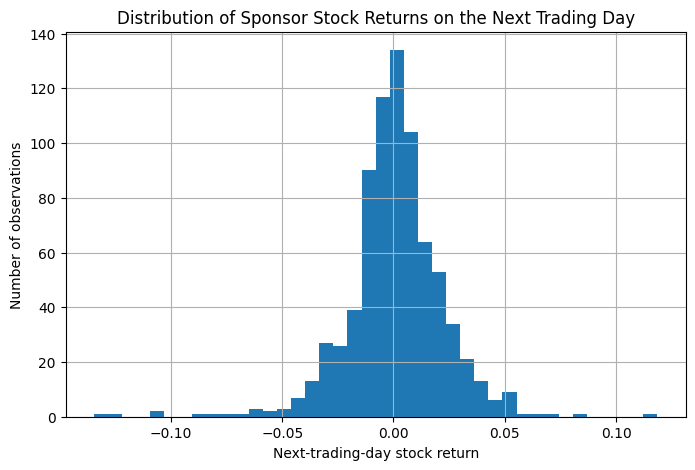

In [16]:
plt.figure(figsize=(8, 5))
regression_data["stock_return_t1"].dropna().hist(bins=40)
plt.title("Distribution of Sponsor Stock Returns on the Next Trading Day")
plt.xlabel("Next-trading-day stock return")
plt.ylabel("Number of observations")
plt.show()

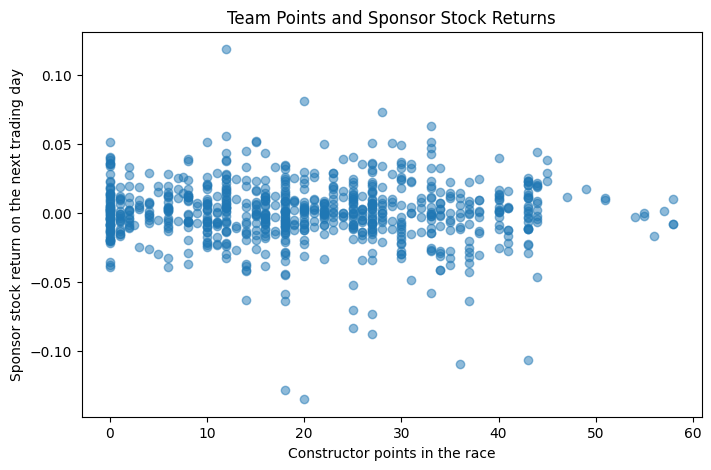

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(regression_data["team_points"], regression_data["stock_return_t1"], alpha=0.5)
plt.title("Team Points and Sponsor Stock Returns")
plt.xlabel("Constructor points in the race")
plt.ylabel("Sponsor stock return on the next trading day")
plt.show()

Two more descriptive checks before we move to regressions: does the *distribution* of next-day returns actually shift when the team wins, and what did each sponsor's stock do over the whole sample, independent of any single race?

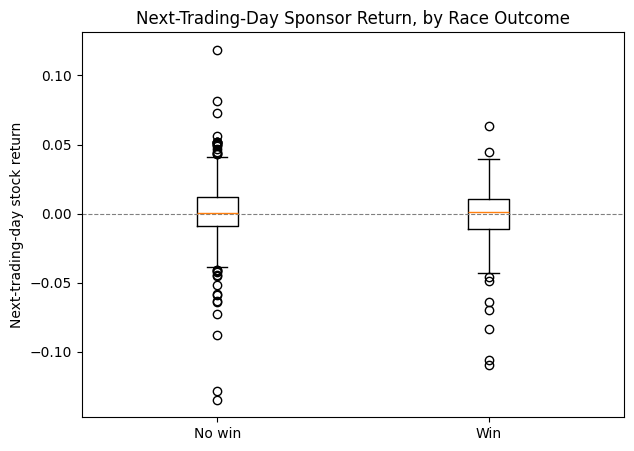

Median return after a win:     0.1057%  (n=148)
Median return after no win:    0.0758%  (n=630)


In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
no_win = regression_data.loc[regression_data["win"] == 0, "stock_return_t1"].dropna()
win = regression_data.loc[regression_data["win"] == 1, "stock_return_t1"].dropna()

ax.boxplot([no_win, win])
ax.set_xticks([1, 2])
ax.set_xticklabels(["No win", "Win"])
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Next-Trading-Day Sponsor Return, by Race Outcome")
ax.set_ylabel("Next-trading-day stock return")
plt.show()

print(f"Median return after a win:    {win.median(): .4%}  (n={len(win)})")
print(f"Median return after no win:   {no_win.median(): .4%}  (n={len(no_win)})")

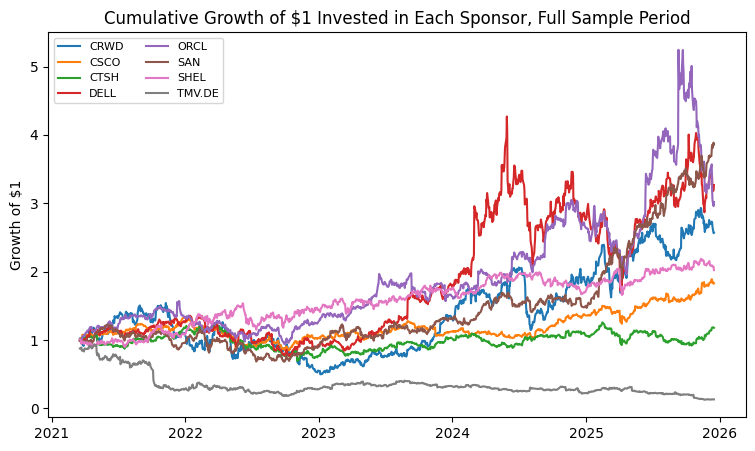

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
for ticker, sub in price_panel[price_panel["ticker"].isin(tickers)].groupby("ticker"):
    sub = sub.sort_values("trading_date").dropna(subset=["return_t1"])
    cumulative_growth = (1 + sub["return_t1"]).cumprod()
    ax.plot(sub["trading_date"], cumulative_growth, label=ticker)

ax.set_title("Cumulative Growth of $1 Invested in Each Sponsor, Full Sample Period")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.show()

## 11. Empirical Methods: Identification, Assumptions, and Why We Cluster Standard Errors

Before looking at a single coefficient, it's worth being explicit about what we are estimating and what it can and cannot tell us — this is the discussion the course slides ask for in the Empirical Methods section of the paper, so we keep it here in the notebook as well so the code and the write-up stay consistent.

**The estimating equation.** Our main specification is

$$
\text{stock\_return\_t1}_{i,r} = \beta_0 + \beta_1 \, \text{win}_{i,r} + \beta_2 \, \text{podium}_{i,r} + \beta_3 \, \text{team\_points}_{i,r} + \beta_4 \, \text{market\_return\_t1}_{i,r} + \beta_5 \, \text{vix\_level\_t1}_{i,r} + u_{i,r}
$$

where $i$ indexes the sponsor's stock and $r$ indexes the race weekend. Our fourth specification adds a full set of year dummies to this equation, which lets the average return level differ by year and absorbs broad macro regimes (2022's bear market versus the recovery afterwards) that have nothing to do with F1 but would otherwise sit in $u_{i,r}$.

**Is strict exogeneity (MLR.4) plausible?** Reverse causality is not really a concern here — a stock's return on the day *after* a race obviously cannot cause last weekend's finishing position. The harder question is whether $u_{i,r}$ is correlated with $\text{win}_{i,r}$ through some omitted factor. We think this is unlikely to be a first-order problem at the *scale* of these companies: Oracle, Shell, Cognizant and the rest are multi-billion-dollar firms whose daily returns are dominated by earnings, macro news, and sector-wide moves, not by whichever F1 team they happen to sponsor. That actually cuts the other way for inference: it's not that we expect a biased estimate, it's that we expect the *true* effect of one race result on the stock price to be extremely small relative to the noise in daily returns, so a statistically insignificant coefficient should be read as "we don't have enough power to detect an effect this small," not as "F1 performance definitely has no effect on sponsor value."

**Selection.** Only six constructors (Red Bull, Mercedes, Ferrari, McLaren, Aston Martin, Williams) have a sponsor whose stock we can actually observe; the rest of the grid (Alpine, Haas, etc.) is dropped simply because we have no listed company to track. These six are not a random sample of F1 teams — they tend to be the better-funded, more sponsor-attractive teams. We don't think this creates a textbook endogeneity bias inside the regression itself, but it does limit how far we can generalize our results beyond "well-resourced teams with single, clearly identifiable sponsors."

**Why we cluster standard errors by race date.** Every race weekend can generate up to six observations at once (one per sponsor), and several of these share more than just a calendar date: they share the exact same `market_return_t1` and `vix_level_t1` values by construction, and `win`/`podium` are mechanically linked across teams in the same race (only one team can win). That means the residuals for different sponsors observed on the same race date are very unlikely to be independent — plain heteroskedasticity-robust standard errors (`HC1`) assume independence across *all* observations and would understate the true uncertainty here. We address this by clustering standard errors at the race level (`raceId`), which only requires independence *across* races, not within them.

In [20]:
def run_ols(df, y_col, x_cols, cluster_col=None):
    needed_cols = [y_col] + x_cols + ([cluster_col] if cluster_col else [])
    model_df = df[needed_cols].dropna().copy()
    y = model_df[y_col]
    X = sm.add_constant(model_df[x_cols])
    if cluster_col:
        # Cluster-robust standard errors, grouped by race: this accounts for the
        # fact that several sponsor observations from the same race weekend
        # share the same market/VIX controls and a mechanically linked outcome.
        model = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": model_df[cluster_col]})
    else:
        model = sm.OLS(y, X).fit(cov_type="HC1")
    return model, model_df

model_1, model_1_df = run_ols(regression_data, "stock_return_t1", ["win"], cluster_col="raceId")
model_2, model_2_df = run_ols(regression_data, "stock_return_t1", ["win", "market_return_t1", "vix_level_t1"], cluster_col="raceId")

model_3_cols = ["win", "podium", "team_points", "market_return_t1", "vix_level_t1"]
model_3, model_3_df = run_ols(regression_data, "stock_return_t1", model_3_cols, cluster_col="raceId")

# Model 4: same as Model 3, plus year fixed effects to absorb broad macro regimes
# (2022's bear market vs. the recovery afterwards) that have nothing to do with F1.
year_dummies = pd.get_dummies(regression_data["year"], prefix="year", drop_first=True).astype(float)
regression_data = pd.concat([regression_data, year_dummies], axis=1)
year_dummy_cols = list(year_dummies.columns)

model_4_cols = model_3_cols + year_dummy_cols
model_4, model_4_df = run_ols(regression_data, "stock_return_t1", model_4_cols, cluster_col="raceId")

print("Model 1 (n =", int(model_1.nobs), ") through Model 4 (n =", int(model_4.nobs), ") estimated.")
print("Year dummy columns added in Model 4:", year_dummy_cols)

Model 1 (n = 778 ) through Model 4 (n = 778 ) estimated.
Year dummy columns added in Model 4: ['year_2022', 'year_2023', 'year_2024', 'year_2025']


In [21]:
model_t3_cols = [
    "win",
    "podium",
    "team_points",
    "market_return_t1",
    "vix_level_t1"
]

model_t3, model_t3_df = run_ols(
    regression_data,
    "stock_return_t3",
    model_t3_cols,
    cluster_col="raceId"
)

print(model_t3.summary())

                            OLS Regression Results                            
Dep. Variable:        stock_return_t3   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     5.741
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           9.29e-05
Time:                        01:36:55   Log-Likelihood:                 1347.4
No. Observations:                 778   AIC:                            -2683.
Df Residuals:                     772   BIC:                            -2655.
Df Model:                           5                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0372      0.014  

## 12. Side-by-Side Model Comparison

Rather than printing four separate `.summary()` blocks, we put all four specifications next to each other in one table — this is the same layout the course slides use for the results section, and it makes it much easier to see how the coefficient on `win` (the variable we actually care about) behaves as we add controls.

In [22]:
comparison = summary_col(
    [model_1, model_2, model_3, model_4],
    model_names=["(1)", "(2)", "(3)", "(4) Year FE"],
    stars=True,
    float_format="%0.4f",
    info_dict={"N": lambda m: f"{int(m.nobs)}"},
)
print(comparison)

comparison_df = comparison.tables[0]
comparison_df


                   (1)       (2)       (3)    (4) Year FE
---------------------------------------------------------
const            0.0014   0.0030    0.0021    -0.0012    
                 (0.0012) (0.0021)  (0.0023)  (0.0032)   
win              -0.0036  -0.0033   -0.0042   -0.0041    
                 (0.0023) (0.0022)  (0.0029)  (0.0028)   
market_return_t1          1.0361*** 1.0394*** 1.0146***  
                          (0.0610)  (0.0601)  (0.0664)   
vix_level_t1              -0.0001   -0.0001   -0.0002    
                          (0.0001)  (0.0001)  (0.0001)   
podium                              -0.0017   -0.0015    
                                    (0.0026)  (0.0026)   
team_points                         0.0001    0.0001     
                                    (0.0001)  (0.0001)   
year_2022                                     0.0045*    
                                              (0.0025)   
year_2023                                     0.0049**   
             

,(1),(2),(3),(4) Year FE
const,0.0014,0.0030,0.0021,-0.0012
,(0.0012),(0.0021),(0.0023),(0.0032)
win,-0.0036,-0.0033,-0.0042,-0.0041
,(0.0023),(0.0022),(0.0029),(0.0028)
market_return_t1,,1.0361***,1.0394***,1.0146***
,,(0.0610),(0.0601),(0.0664)
vix_level_t1,,-0.0001,-0.0001,-0.0002
,,(0.0001),(0.0001),(0.0001)
podium,,,-0.0017,-0.0015
,,,(0.0026),(0.0026)


## 13. Time-Series Diagnostics: Stationarity and Serial Correlation

Two assumptions are worth checking directly rather than just asserting, since they map onto things we specifically covered in the time-series part of the course.

**Stationarity.** Our whole analysis is built on *returns*, not price *levels*, and the reason is exactly the stationarity property we covered in class: price levels tend to wander (a random walk has no fixed mean or variance over time), while returns are typically stationary, which is what makes standard OLS inference valid in the first place. We check this with an Augmented Dickey-Fuller (ADF) test on both the price level and the return series for every ticker — we expect to reject the unit-root null for returns and fail to reject it for price levels.

**Serial correlation.** Clustering by race date (Section 11) handles dependence *within* the same race date, but it does not rule out dependence *across* race dates for the same sponsor — for example, if a surprisingly bad return after one race tends to be followed by another bad return next time. We test for that directly with a Breusch-Godfrey test on the residuals of our most complete specification (Model 4), after sorting the data chronologically so the lag structure is meaningful. If this test flagged serial correlation, the natural next step would be Newey-West (HAC) standard errors instead of (or alongside) the cluster-robust ones we use above; we report the test here mainly as a check on that assumption.

In [23]:
adf_rows = []
for ticker in tickers + ["^GSPC"]:
    series = price_panel[price_panel["ticker"] == ticker].sort_values("trading_date")
    level_series = series["adj_close"].dropna()
    return_series = series["return_t1"].dropna()

    level_pvalue = adfuller(level_series)[1] if len(level_series) > 10 else np.nan
    return_pvalue = adfuller(return_series)[1] if len(return_series) > 10 else np.nan

    adf_rows.append({
        "ticker": ticker,
        "adf_pvalue_level": level_pvalue,
        "adf_pvalue_return": return_pvalue,
        "level_is_stationary_at_5pct": level_pvalue < 0.05 if pd.notna(level_pvalue) else np.nan,
        "return_is_stationary_at_5pct": return_pvalue < 0.05 if pd.notna(return_pvalue) else np.nan,
    })

adf_table = pd.DataFrame(adf_rows)
print("Augmented Dickey-Fuller test results (H0: the series has a unit root / is non-stationary):")
adf_table

Augmented Dickey-Fuller test results (H0: the series has a unit root / is non-stationary):


,ticker,adf_pvalue_level,adf_pvalue_return,level_is_stationary_at_5pct,return_is_stationary_at_5pct
0,CRWD,0.881159,0.000000e+00,False,True
1,CSCO,0.988310,0.000000e+00,False,True
2,CTSH,0.219731,0.000000e+00,False,True
3,DELL,0.865294,0.000000e+00,False,True
4,ORCL,0.559320,0.000000e+00,False,True
5,SAN,1.000000,1.556648e-27,False,True
6,SHEL,0.582964,0.000000e+00,False,True
7,TMV.DE,0.000323,0.000000e+00,True,True
8,^GSPC,0.968840,0.000000e+00,False,True


In [24]:
# Re-fit Model 4 on a chronologically sorted copy of the data so the lag
# structure used by the Breusch-Godfrey test is meaningful. The coefficients
# are identical to model_4 above; only the residual ordering changes.
sort_col = "trading_date" if "trading_date" in regression_data.columns else "date"
regression_data_sorted = regression_data.sort_values(sort_col)
model_4_sorted, _ = run_ols(regression_data_sorted, "stock_return_t1", model_4_cols, cluster_col="raceId")

bg_stat, bg_pvalue, bg_fstat, bg_fpvalue = acorr_breusch_godfrey(model_4_sorted, nlags=5)

print(f"Breusch-Godfrey test for serial correlation (5 lags): LM stat = {bg_stat:.3f}, p-value = {bg_pvalue:.4f}")
if bg_pvalue < 0.05:
    print("We reject the null of no serial correlation at the 5% level -- Newey-West (HAC) standard errors")
    print("would be a more conservative choice than the cluster-robust ones used above.")
else:
    print("We fail to reject the null of no serial correlation at the 5% level -- this supports using the")
    print("cluster-robust standard errors from Section 11 as our main inference approach.")

Breusch-Godfrey test for serial correlation (5 lags): LM stat = 8.612, p-value = 0.1256
We fail to reject the null of no serial correlation at the 5% level -- this supports using the
cluster-robust standard errors from Section 11 as our main inference approach.


## 14. Save the analysis datasets

The output files are saved in the `outputs/` folder so they can be used later in the paper or for additional checks. Besides the datasets we already had, we now also save the model comparison table and the stationarity diagnostics, since those will likely end up as tables in the paper too.

In [25]:
team_race.to_csv(OUTPUT_DIR / "team_race_performance.csv", index=False)
analysis_base.to_csv(OUTPUT_DIR / "sponsor_race_base.csv", index=False)
regression_data.to_csv(OUTPUT_DIR / "regression_dataset.csv", index=False)
summary_stats.to_csv(OUTPUT_DIR / "summary_statistics.csv")
comparison_df.to_csv(OUTPUT_DIR / "model_comparison_table.csv")
adf_table.to_csv(OUTPUT_DIR / "adf_stationarity_table.csv", index=False)

print("Saved files:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", file)

Saved files:
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/adf_stationarity_table.csv
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/model_comparison_table.csv
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/price_panel_cache.csv
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/regression_dataset.csv
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/sponsor_race_base.csv
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/summary_statistics.csv
- /Users/wayne/Desktop/Exchange/f1-sponsor-stocks/outputs/team_race_performance.csv


## Limitations and Possible Extensions

A few things we deliberately left out, mostly because of the time available for this version of the project, but that are worth naming honestly in the paper's conclusion as next steps rather than pretending they don't matter:

- **Beta estimation.** Our "abnormal return" is just the raw return minus the market return, which implicitly assumes a beta of 1 for every sponsor. A more standard event-study approach would estimate each stock's own beta from a pre-event estimation window and use that to compute abnormal returns, which would be a more accurate (if more involved) measure of the F1-specific component of the move.
- **Cointegration.** Since we have multi-year price and performance series for the same six teams, a natural extension would be to test whether a sponsor's stock price and its team's cumulative championship points are cointegrated over a season — i.e. whether they share a long-run common trend rather than just a short-run, race-by-race correlation. We did not pursue this here given the page and time constraints, but it would fit naturally with the cointegration material from the course.
- **Sample composition.** As discussed in Section 11, our six eligible sponsors are not a random sample of F1 teams. A future version could try to address this more formally (e.g. by checking whether results are similar for the better- vs. worse-funded teams in our sample) rather than just flagging it as a caveat.